# 04 — Environmental Similarity Search

**Research question:** Which plots on the Big Island most resemble Kaʻu and Kona coffee farms in terms of terrain, climate, and soil?

Parts A–C: analog finder, expansion suitability map, island-wide topographic identity.

Climate-forward projections are in **`05_forward_projection.ipynb`**.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

DATA = '../data'
IMG  = '../img'
BG   = 'white'
SPLIT_LON = -155.7279

def clip_cmap(name, lo=0.0, hi=0.9):
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_clip', base(np.linspace(lo, hi, 256)))

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df        = pd.read_pickle(f'{DATA}/df.pkl')            # 385 coffee cells, all features
elev_feat = pd.read_pickle(f'{DATA}/plot_all_features.pkl')  # 10,211 grid cells, topo + soil

coffee = df[df['label'] == 1].copy()
print(f'Coffee cells: {len(coffee)}  (Kona={len(coffee[coffee.region=="kona"])}, Kaʻu={len(coffee[coffee.region=="kau"])})')

# ── Feature sets ──────────────────────────────────────────────────────────────
# Full feature set (incl. climate) — used for between-region distinctiveness only.
# NOTE: PRISM climate is 4km resolution: Ka'u has only 4 distinct temp values
# across 62 plots, so it effectively acts as a region label, not a plot discriminator.
FULL_FEATS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m',
    'temp_mean', 'temp_range', 'gdd', 'precip_annual', 'precip_dry_frac', 'wind_speed_mean',
    'ndvi_median',
    'drain_ord', 'restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
]

# Plot-level feature set — no climate (too coarse to differentiate individual plots).
# Used for the analog finder: within Ka'u, climate is ~identical, so topo+soil+NDVI
# is what actually distinguishes one farm from another.
PLOT_FEATS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m',
    'ndvi_median',
    'drain_ord', 'restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
]

# Topo-only — fallback for Part B cells without SSURGO coverage (young lava flows, etc.)
TOPO_FEATS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m',
]

# Topo+soil — used for Part B suitability scoring where SSURGO data is available.
# NDVI excluded: it reflects how well coffee already grows, not site potential.
SITE_FEATS = TOPO_FEATS + [
    'drain_ord', 'restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
]

print(f'Full feature set:      {len(FULL_FEATS)} features  (incl. climate — for region comparison)')
print(f'Plot-level feat set:   {len(PLOT_FEATS)} features  (no climate — for analog finder)')
print(f'Topo feature set:      {len(TOPO_FEATS)} features  (fallback for cells without soil)')
print(f'Topo+soil feat set:    {len(SITE_FEATS)} features  (Part B — where SSURGO available)')

Coffee cells: 317  (Kona=258, Kaʻu=59)
Full feature set:      20 features  (incl. climate — for region comparison)
Plot-level feat set:   14 features  (no climate — for analog finder)
Topo feature set:      8 features  (fallback for cells without soil)
Topo+soil feat set:    13 features  (Part B — where SSURGO available)


## Part A — Analog Finder

Fit a nearest-neighbor index on all 385 coffee cells using the full
feature set. For each plot, return its *K* closest analogs ranked by
Euclidean distance in standardized feature space.

In [3]:
# ── Fit plot-level scaler and nearest-neighbor index ──────────────────────────
# Uses PLOT_FEATS (topo + soil + NDVI, no climate).
# Climate is too coarse (4km PRISM) to differentiate individual plots within a region.
X_plot = coffee[PLOT_FEATS].values
plot_scaler = StandardScaler()
Xs_plot = plot_scaler.fit_transform(X_plot)

nn = NearestNeighbors(n_neighbors=11, metric='euclidean')  # 11 = self + 10 neighbors
nn.fit(Xs_plot)

distances, indices = nn.kneighbors(Xs_plot)

dist_neighbors = distances[:, 1:]   # shape (385, 10) — drop self
idx_neighbors  = indices[:, 1:]

print('Nearest-neighbor index fitted on PLOT_FEATS.')
print(f'Mean distance to nearest neighbor: {dist_neighbors[:,0].mean():.3f} (scaled units)')

Nearest-neighbor index fitted on PLOT_FEATS.
Mean distance to nearest neighbor: 1.164 (scaled units)


In [4]:
# ── Quantify Ka'u distinctiveness (using FULL_FEATS incl. climate) ────────────
X_full = coffee[FULL_FEATS].values
full_scaler = StandardScaler()
Xs_full = full_scaler.fit_transform(X_full)

kona_pos = np.where(coffee.region.values == 'kona')[0]
kau_pos  = np.where(coffee.region.values == 'kau')[0]

Xs_kona = Xs_full[kona_pos]
Xs_kau  = Xs_full[kau_pos]

kona_centroid = Xs_kona.mean(axis=0)
kau_centroid  = Xs_kau.mean(axis=0)

kona_to_kona = np.linalg.norm(Xs_kona - kona_centroid, axis=1).mean()
kona_to_kau  = np.linalg.norm(Xs_kona - kau_centroid,  axis=1).mean()
kau_to_kau   = np.linalg.norm(Xs_kau  - kau_centroid,  axis=1).mean()
kau_to_kona  = np.linalg.norm(Xs_kau  - kona_centroid, axis=1).mean()

centroid_sep = np.linalg.norm(kona_centroid - kau_centroid)
ratio = centroid_sep / ((kona_to_kona + kau_to_kau) / 2)

print('Environmental distinctiveness (scaled Euclidean, full feature set):')
print(f'  Kona internal spread : {kona_to_kona:.3f}')
print(f'  Kaʻu internal spread : {kau_to_kau:.3f}')
print(f'  Centroid separation  : {centroid_sep:.3f}')
print(f'  Separation / avg spread = {ratio:.2f}')
print(f'  (>1 = regions more different from each other than internally coherent)')
print()
# Also compute using PLOT_FEATS for comparison
Xs_kona_plot = Xs_plot[kona_pos]
Xs_kau_plot  = Xs_plot[kau_pos]
kona_c_plot  = Xs_kona_plot.mean(axis=0)
kau_c_plot   = Xs_kau_plot.mean(axis=0)
sep_plot = np.linalg.norm(kona_c_plot - kau_c_plot)
spread_plot = (np.linalg.norm(Xs_kona_plot - kona_c_plot, axis=1).mean() +
               np.linalg.norm(Xs_kau_plot  - kau_c_plot,  axis=1).mean()) / 2
print(f'  Topo+soil+NDVI only — separation/spread = {sep_plot/spread_plot:.2f}')
print(f'  (Climate dominates the between-region gap; topo alone still separates them)')

Environmental distinctiveness (scaled Euclidean, full feature set):
  Kona internal spread : 3.205
  Kaʻu internal spread : 3.589
  Centroid separation  : 7.053
  Separation / avg spread = 2.08
  (>1 = regions more different from each other than internally coherent)

  Topo+soil+NDVI only — separation/spread = 1.80
  (Climate dominates the between-region gap; topo alone still separates them)


In [5]:
# ── Cross-region neighbor depth ───────────────────────────────────────────────
# For Ka'u plots: at what rank does the FIRST Kona neighbor appear?
# (Using 100 neighbors to search deep enough to find cross-region hits.)
nn_deep = NearestNeighbors(n_neighbors=100, metric='euclidean')
nn_deep.fit(Xs_plot)
dist_deep, idx_deep = nn_deep.kneighbors(Xs_plot)

region_arr = coffee.region.values
kau_pos_list  = np.where(region_arr == 'kau')[0]
kona_pos_list = np.where(region_arr == 'kona')[0]

# Ka'u → first Kona neighbor rank
kau_first_kona_rank = []
kau_first_kona_dist = []
for i in kau_pos_list:
    for rank, idx in enumerate(idx_deep[i, 1:], start=1):
        if region_arr[idx] == 'kona':
            kau_first_kona_rank.append(rank)
            kau_first_kona_dist.append(dist_deep[i, rank])
            break

kau_nn_dist = dist_deep[kau_pos_list, 1]  # within-Ka'u nearest neighbor distance

print('Ka\'u → Kona environmental gap:')
print(f'  Median rank of first Kona neighbor: {np.median(kau_first_kona_rank):.0f}')
print(f'  Min rank of first Kona neighbor:    {min(kau_first_kona_rank)}')
print(f'  Median distance to first Kona hit:  {np.median(kau_first_kona_dist):.3f}')
print(f'  Median within-Kaʻu nearest dist:    {np.median(kau_nn_dist):.3f}')
ratio = np.median(kau_first_kona_dist) / np.median(kau_nn_dist)
print(f'  Distance ratio (Kona / Kaʻu-NN):    {ratio:.1f}×')
print()
print(f'Interpretation:')
print(f'  A typical Ka\'u farm must search through rank {int(np.median(kau_first_kona_rank))} before')
print(f'  finding a single Kona analog — and when it does, that Kona farm is')
print(f'  {ratio:.1f}× farther in environmental space than Ka\'u\'s nearest Ka\'u neighbor.')
print()
print(f'  This quantitatively supports Ka\'u\'s distinct appellation: these are')
print(f'  not interchangeable terroirs.')

Ka'u → Kona environmental gap:
  Median rank of first Kona neighbor: 49
  Min rank of first Kona neighbor:    3
  Median distance to first Kona hit:  5.213
  Median within-Kaʻu nearest dist:    1.312
  Distance ratio (Kona / Kaʻu-NN):    4.0×

Interpretation:
  A typical Ka'u farm must search through rank 49 before
  finding a single Kona analog — and when it does, that Kona farm is
  4.0× farther in environmental space than Ka'u's nearest Ka'u neighbor.

  This quantitatively supports Ka'u's distinct appellation: these are
  not interchangeable terroirs.


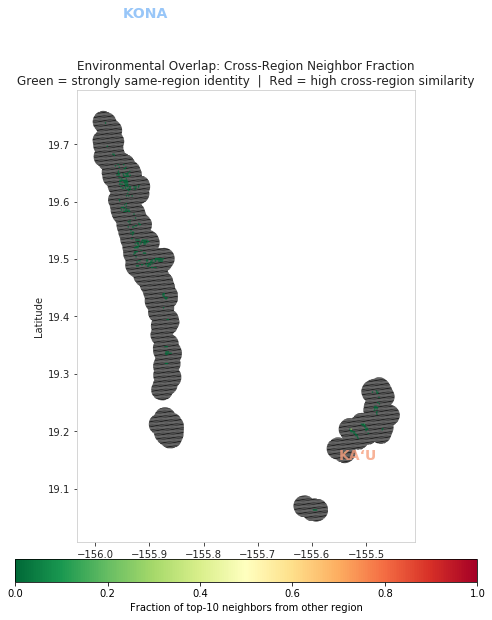

Saved 04_cross_region_map.png


In [6]:
# ── Distinctiveness map: cross-region neighbor fraction (top-10) ──────────────
# For each coffee cell, what fraction of its top-10 nearest neighbors are from
# the other region? Computed from the deep neighbor index (nn_deep).
cross_frac = np.array([
    np.sum(region_arr[idx_deep[i, 1:11]] != region_arr[i]) / 10
    for i in range(len(coffee))
])

grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')
gdf  = gpd.GeoDataFrame(grid, geometry='geometry', crs='EPSG:4326')

coffee = coffee.copy()
coffee['cross_frac'] = cross_frac

plot_geo   = coffee.merge(gdf[['plot_id','geometry']], on='plot_id', how='left')
gdf_coffee = gpd.GeoDataFrame(plot_geo, geometry='geometry', crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

gdf.plot(ax=ax, color='#222222', edgecolor='none', linewidth=0)
gdf_coffee.plot(
    ax=ax, column='cross_frac', cmap='RdYlGn_r',
    vmin=0, vmax=1, markersize=4, legend=True,
    legend_kwds={'label': 'Fraction of top-10 neighbors from other region',
                 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.03}
)

ax.set_title('Environmental Overlap: Cross-Region Neighbor Fraction\n'
             'Green = strongly same-region identity  |  Red = high cross-region similarity',
             color='#222222', fontsize=12)
ax.tick_params(colors='#222222')
ax.set_xlabel('Longitude', color='#222222')
ax.set_ylabel('Latitude', color='#222222')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

ax.text(-155.95, 19.92, 'KONA', color='#7eb8f7', fontsize=14, fontweight='bold', alpha=0.8)
ax.text(-155.55, 19.15, "KAʻU", color='#f7a07e', fontsize=14, fontweight='bold', alpha=0.8)

plt.tight_layout()
plt.savefig(f'{IMG}/04_cross_region_map.png', dpi=150, facecolor=BG)
plt.show()
print('Saved 04_cross_region_map.png')

In [7]:
# ── Analog lookup function ────────────────────────────────────────────────────
def find_analogs(plot_id, k=5, verbose=True):
    """
    Given a plot_id, return its k nearest environmental analogs.
    Returns a DataFrame with distance and region for each analog.
    """
    row_pos = coffee.index.get_loc(coffee.index[coffee['plot_id'] == plot_id][0])
    dists   = dist_neighbors[row_pos, :k]
    idxs    = idx_neighbors[row_pos, :k]

    analogs = coffee.iloc[idxs][['plot_id', 'region', 'elev_mean', 'temp_mean',
                                  'precip_annual', 'ndvi_median']].copy()
    analogs.insert(0, 'rank', range(1, k+1))
    analogs.insert(1, 'distance', dists.round(3))
    analogs = analogs.reset_index(drop=True)

    if verbose:
        query = coffee[coffee['plot_id'] == plot_id].iloc[0]
        print(f'Query plot {plot_id} ({query.region.upper()})')
        print(f'  Elev={query.elev_mean:.0f}m  Temp={query.temp_mean:.1f}°C  '
              f'Precip={query.precip_annual:.0f}mm  NDVI={query.ndvi_median:.3f}')
        print()
        print('Top analogs:')
        print(analogs.to_string(index=False))
    return analogs

# Demo: find analogs for a Ka'u plot
kau_plots = coffee[coffee.region == 'kau']['plot_id'].values
best_kau  = coffee[coffee.region == 'kau'].sort_values('ndvi_median', ascending=False).iloc[0]['plot_id']
print('=== Best-NDVI Kaʻu plot ===')
analogs = find_analogs(int(best_kau), k=8)

=== Best-NDVI Kaʻu plot ===
Query plot 1521 (KAU)
  Elev=473m  Temp=20.0°C  Precip=702mm  NDVI=0.887

Top analogs:
 rank  distance  plot_id region  elev_mean  temp_mean  precip_annual  ndvi_median
    1     2.263     1520    kau 485.847346  20.015504     701.722214     0.828061
    2     2.480     1755    kau 556.593023  20.015504     701.722214     0.772565
    3     2.495     2793    kau 512.869330  20.015504     701.722214     0.687208
    4     2.625     1677    kau 524.617431  20.015504     701.722214     0.717931
    5     2.731     1445    kau 459.280268  20.015504     701.722214     0.667546
    6     2.820     1598    kau 510.768127  20.015504     701.722214     0.741203
    7     2.992     1372    kau 437.297069  20.015504     701.722214     0.675804
    8     3.220     1597    kau 521.107337  20.015504     701.722214     0.703494


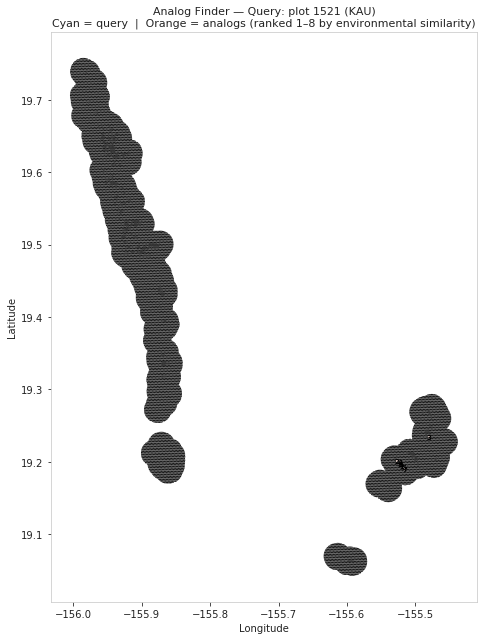

Saved ../img/04_analog_map_1521.png


In [8]:
# ── Map: query plot + its analogs ─────────────────────────────────────────────
def map_analogs(plot_id, k=8):
    analogs   = find_analogs(plot_id, k=k, verbose=False)
    query_row = coffee[coffee['plot_id'] == plot_id].merge(
                    gdf[['plot_id','geometry']], on='plot_id')
    query_gdf = gpd.GeoDataFrame(query_row, geometry='geometry', crs='EPSG:4326')

    analog_rows = coffee[coffee['plot_id'].isin(analogs['plot_id'])].merge(
                      gdf[['plot_id','geometry']], on='plot_id')
    analog_gdf  = gpd.GeoDataFrame(analog_rows, geometry='geometry', crs='EPSG:4326')
    analog_gdf  = analog_gdf.merge(analogs[['plot_id','rank','distance']], on='plot_id')

    fig, ax = plt.subplots(figsize=(11, 9))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    gdf.plot(ax=ax, color='#1a1a1a', edgecolor='none')
    gdf_coffee.plot(ax=ax, color='#333333', markersize=3)

    # Analogs colored by rank (closest = brightest)
    analog_gdf.plot(ax=ax, color='#f7a07e', markersize=60, alpha=0.85,
                    edgecolor='white', linewidth=0.5)

    # Query plot on top
    query_gdf.plot(ax=ax, color='#00e5ff', markersize=120,
                   edgecolor='white', linewidth=1.0)

    # Rank labels
    for _, row in analog_gdf.iterrows():
        ax.annotate(str(row['rank']),
                    xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                    ha='center', va='center', fontsize=7, color='black', fontweight='bold')

    query_info = coffee[coffee['plot_id'] == plot_id].iloc[0]
    ax.set_title(
        f'Analog Finder — Query: plot {plot_id} ({query_info.region.upper()})\n'
        f'Cyan = query  |  Orange = analogs (ranked 1–{k} by environmental similarity)',
        color='#222222', fontsize=11)
    ax.tick_params(colors='#222222')
    ax.set_xlabel('Longitude', color='#222222')
    ax.set_ylabel('Latitude', color='#222222')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

    plt.tight_layout()
    fname = f'{IMG}/04_analog_map_{plot_id}.png'
    plt.savefig(fname, dpi=150, facecolor=BG)
    plt.show()
    print(f'Saved {fname}')

map_analogs(int(best_kau), k=8)

## Part B — Expansion Suitability Map

Score every grid cell by its environmental similarity to the Ka'u and Kona coffee profiles.

**Scoring strategy (hybrid):**
- Cells with SSURGO soil coverage use **topo + soil** features (13 features): captures the Ka'u signature of younger, more restrictive volcanic soils (lower restriction depth, higher OM, lower AWC vs Kona).
- Cells without SSURGO coverage (recent lava flows, ocean grid edges) fall back to **topo-only** (8 features).

**Ka'u score** = inverse distance to the Ka'u coffee centroid in feature space  
**Kona score** = inverse distance to the Kona coffee centroid in feature space  
**Identity** = Ka'u score − Kona score (positive = Ka'u-like, negative = Kona-like)

In [9]:
# ── Topo-only scaler (fallback for cells without SSURGO coverage) ─────────────
X_topo_coffee = coffee[TOPO_FEATS].values
topo_scaler   = StandardScaler()
Xs_topo_coffee = topo_scaler.fit_transform(X_topo_coffee)

kona_topo_centroid = Xs_topo_coffee[kona_pos].mean(axis=0)
kau_topo_centroid  = Xs_topo_coffee[kau_pos].mean(axis=0)

# ── Topo+soil scaler (used for cells with SSURGO coverage) ───────────────────
X_site_coffee = coffee[SITE_FEATS].values
site_scaler   = StandardScaler()
Xs_site_coffee = site_scaler.fit_transform(X_site_coffee)

kona_site_centroid = Xs_site_coffee[kona_pos].mean(axis=0)
kau_site_centroid  = Xs_site_coffee[kau_pos].mean(axis=0)

print(f'Topo centroid separation:       {np.linalg.norm(kona_topo_centroid - kau_topo_centroid):.3f}')
print(f'Topo+soil centroid separation:  {np.linalg.norm(kona_site_centroid - kau_site_centroid):.3f}')

# ── Score all grid cells ──────────────────────────────────────────────────────
# Drop edge cells missing topo values.
elev_valid = elev_feat.dropna(subset=TOPO_FEATS).copy()

# Cells with SSURGO soil data (soil_null==0, all SITE_FEATS present) use
# topo+soil features. Young lava flows and unmapped areas fall back to topo-only.
has_soil = (
    (elev_valid['soil_null'].fillna(1) == 0) &
    elev_valid[SITE_FEATS].notna().all(axis=1)
).values
n_soil = has_soil.sum()

def dist_to_score(d):
    """Convert Euclidean distance to similarity score (higher = more similar)."""
    return 1 / (1 + d)

# Baseline: score all cells with topo-only
Xs_topo_all = topo_scaler.transform(elev_valid[TOPO_FEATS].values)
kona_score = dist_to_score(np.linalg.norm(Xs_topo_all - kona_topo_centroid, axis=1))
kau_score  = dist_to_score(np.linalg.norm(Xs_topo_all - kau_topo_centroid,  axis=1))

# Override with richer topo+soil scores for SSURGO-covered cells
if n_soil > 0:
    Xs_site_soil = site_scaler.transform(elev_valid[SITE_FEATS].values[has_soil])
    kona_score[has_soil] = dist_to_score(np.linalg.norm(Xs_site_soil - kona_site_centroid, axis=1))
    kau_score[has_soil]  = dist_to_score(np.linalg.norm(Xs_site_soil - kau_site_centroid,  axis=1))

identity = kau_score - kona_score  # positive = Ka'u-like

elev_valid['kona_score']   = kona_score
elev_valid['kau_score']    = kau_score
elev_valid['kau_identity'] = identity
elev_valid['used_soil']    = has_soil  # diagnostic: True where topo+soil was used

print(f'Scored {len(elev_valid):,} grid cells ({len(elev_feat)-len(elev_valid)} edge cells dropped).')
print(f'  {n_soil:,} cells scored with topo+soil features (SSURGO covered)')
print(f'  {len(elev_valid)-n_soil:,} cells scored with topo-only (no SSURGO coverage)')
print(f'Identity range: {identity.min():.3f} to {identity.max():.3f}')

Topo centroid separation:       4.086
Topo+soil centroid separation:  5.265
Scored 10,179 grid cells (32 edge cells dropped).
  9,322 cells scored with topo+soil features (SSURGO covered)
  857 cells scored with topo-only (no SSURGO coverage)
Identity range: -0.370 to 0.353


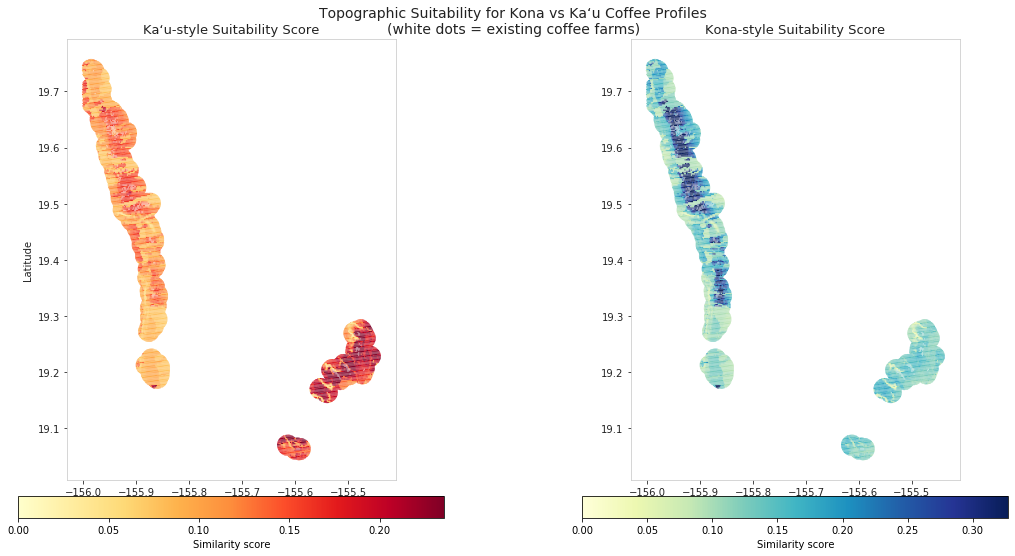

Saved 04_suitability_map.png


In [10]:
# ── Expansion suitability map ─────────────────────────────────────────────────
gdf_all = gpd.GeoDataFrame(elev_valid, geometry='geometry', crs='EPSG:4326')

# Load coffee farm geometries for overlay
grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')
gdf  = gpd.GeoDataFrame(grid, geometry='geometry', crs='EPSG:4326')

coffee_geo = coffee.merge(gdf[['plot_id','geometry']], on='plot_id', how='left')
gdf_coffee = gpd.GeoDataFrame(coffee_geo, geometry='geometry', crs='EPSG:4326')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG)

titles = ['Kaʻu-style Suitability Score', 'Kona-style Suitability Score']
cols   = ['kau_score', 'kona_score']
cmaps  = ['YlOrRd', 'YlGnBu']

for ax, col, title, cmap in zip(axes, cols, titles, cmaps):
    ax.set_facecolor(BG)
    gdf_all.plot(ax=ax, column=col, cmap=cmap, vmin=0, vmax=gdf_all[col].quantile(0.95),
                 legend=True,
                 legend_kwds={'label': 'Similarity score', 'orientation': 'horizontal',
                              'shrink': 0.6, 'pad': 0.03})
    gdf_coffee.plot(ax=ax, color='white', markersize=4, alpha=0.5)
    ax.set_title(title, color='#222222', fontsize=13)
    ax.tick_params(colors='#222222')
    ax.set_xlabel('Longitude', color='#222222')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

axes[0].set_ylabel('Latitude', color='#222222')
fig.suptitle("Topographic Suitability for Kona vs Kaʻu Coffee Profiles\n"
             "(white dots = existing coffee farms)", color='#222222', fontsize=14, y=1.01)

plt.tight_layout()
plt.savefig(f'{IMG}/04_suitability_map.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print('Saved 04_suitability_map.png')

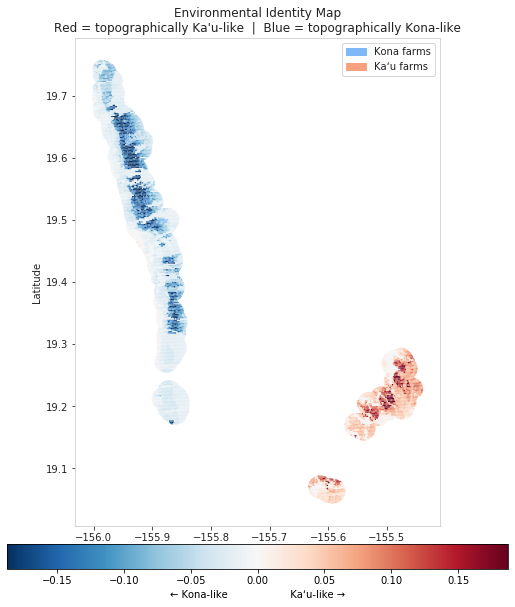

Saved 04_identity_map.png


In [11]:
# ── Identity map: Ka'u-like vs Kona-like ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Diverging: blue = Kona-like, red = Ka'u-like
vmax = np.abs(gdf_all['kau_identity']).quantile(0.95)
gdf_all.plot(ax=ax, column='kau_identity', cmap='RdBu_r',
             vmin=-vmax, vmax=vmax, legend=True,
             legend_kwds={'label': '← Kona-like                    Kaʻu-like →',
                          'orientation': 'horizontal', 'shrink': 0.65, 'pad': 0.03})

# Overlay coffee farms using manual patches for legend (matplotlib 3.1 compat)
kona_geo = gdf_coffee[gdf_coffee.region == 'kona']
kau_geo  = gdf_coffee[gdf_coffee.region == 'kau']
kona_geo.plot(ax=ax, color='#7eb8f7', markersize=8, alpha=0.7)
kau_geo.plot( ax=ax, color='#f7a07e', markersize=8, alpha=0.7)

kona_patch = mpatches.Patch(color='#7eb8f7', label='Kona farms')
kau_patch  = mpatches.Patch(color='#f7a07e', label="Kaʻu farms")
legend = ax.legend(handles=[kona_patch, kau_patch],
                   facecolor='white', framealpha=0.8, loc='upper right')
for text in legend.get_texts():
    text.set_color('#222222')

ax.set_title("Environmental Identity Map\n"
             "Red = topographically Ka'u-like  |  Blue = topographically Kona-like",
             color='#222222', fontsize=12)
ax.tick_params(colors='#222222')
ax.set_xlabel('Longitude', color='#222222')
ax.set_ylabel('Latitude', color='#222222')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig(f'{IMG}/04_identity_map.png', dpi=150, facecolor=BG)
plt.show()
print('Saved 04_identity_map.png')

In [12]:
# ── Summary ───────────────────────────────────────────────────────────────────
total_cells    = len(elev_valid)
kau_territory  = (elev_valid['kau_identity'] > 0).sum()
kona_territory = (elev_valid['kau_identity'] < 0).sum()
strongly_kau   = (elev_valid['kau_identity'] > elev_valid['kau_identity'].quantile(0.75)).sum()

print('Grid summary:')
print(f'  Total scored cells:    {total_cells:,}')
print(f'  Kaʻu-like cells:       {kau_territory:,}  ({kau_territory/total_cells*100:.1f}%)')
print(f'  Kona-like cells:       {kona_territory:,}  ({kona_territory/total_cells*100:.1f}%)')
print(f'  Strongly Kaʻu (top Q): {strongly_kau:,}  ({strongly_kau/total_cells*100:.1f}%)')
print()

kona_geo = gdf_coffee[gdf_coffee.region == 'kona']
kau_geo  = gdf_coffee[gdf_coffee.region == 'kau']
kau_farm_identity  = elev_valid.loc[elev_valid['plot_id'].isin(kau_geo['plot_id']),  'kau_identity']
kona_farm_identity = elev_valid.loc[elev_valid['plot_id'].isin(kona_geo['plot_id']), 'kau_identity']

print('Existing farms vs their topo identity scores:')
print(f'  Kaʻu farms  identity: mean={kau_farm_identity.mean():.3f}  std={kau_farm_identity.std():.3f}')
print(f'  Kona farms  identity: mean={kona_farm_identity.mean():.3f}  std={kona_farm_identity.std():.3f}')
print()
print(f'  Score separation: {kau_farm_identity.mean() - kona_farm_identity.mean():.3f}')

Grid summary:
  Total scored cells:    10,179
  Kaʻu-like cells:       2,750  (27.0%)
  Kona-like cells:       7,429  (73.0%)
  Strongly Kaʻu (top Q): 2,545  (25.0%)

Existing farms vs their topo identity scores:
  Kaʻu farms  identity: mean=0.140  std=0.073
  Kona farms  identity: mean=-0.149  std=0.068

  Score separation: 0.289


## Part C — Island-Wide Topographic Identity Map

Part B scores only the ~10k cells in the existing Kona/Ka'u hex grid.
Here we go island-wide: load the full 10m DEM, block-average to 500m,
compute topo features from scratch for all 36k+ land cells, and re-score
against the Ka'u and Kona coffee centroids.

Key differences from Part B:
- **True coast distance** via distance transform on the land mask (not the
  original lon-based approximation, which only made sense for the west coast)
- **Full Big Island coverage** — includes Kohala, Hamakua, Hilo, Puna, South
  Point and the volcano flanks, not just the coffee belt
- **Internally consistent** — scaler and centroids are fit on coffee cell
  features extracted from the same 500m grid, so everything is apples-to-apples

In [13]:
# ── C1: Load pre-merged 500m island DEM; compute topo features ───────────────
# hawaii_DEM_500m_utm.tif is a gdalwarp average-resampled mosaic of 3 USGS 3DEP
# 1/3 arc-second tiles covering the full Big Island (UTM Zone 4N, EPSG:32604).
import rasterio
from scipy.ndimage import maximum_filter, minimum_filter, distance_transform_edt
from pyproj import Transformer

ISL_DEM = f'{DATA}/DEM/hawaii_DEM_500m_utm.tif'

with rasterio.open(ISL_DEM) as src:
    nd = src.nodata          # -9999.0
    h_b, w_b = src.height, src.width
    dem_500 = src.read(1).astype(np.float32)
    isl_transform = src.transform
    isl_crs = src.crs

# Mask nodata and ocean (≤0)
dem_500[dem_500 == nd] = np.nan
dem_500[dem_500 <= 0]  = np.nan
land_mask = ~np.isnan(dem_500)

# ── Topo features at 500m ──────────────────────────────────────────────────────
scene_mean   = np.nanmean(dem_500[land_mask])
elev_dev_isl = dem_500 - scene_mean

# Fill ocean with scene mean for gradient/filter ops (masked out after)
elev_filled = np.where(land_mask, dem_500, scene_mean)

dy, dx = np.gradient(elev_filled, 500.0, 500.0)
slope_isl      = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
aspect_rad     = np.arctan2(-dx, dy)
aspect_sin_isl = np.sin(aspect_rad)
aspect_cos_isl = np.cos(aspect_rad)

slope_max_isl = maximum_filter(slope_isl,    size=3, mode='nearest')
elev_max_loc  = maximum_filter(elev_filled,   size=3, mode='nearest')
elev_min_loc  = minimum_filter(elev_filled,   size=3, mode='nearest')
relief_isl    = elev_max_loc - elev_min_loc   # total_relief
local_rel_isl = dem_500 - elev_min_loc        # local_relief

# Zero-out ocean pixels in derived arrays
for arr in [elev_dev_isl, slope_isl, slope_max_isl, aspect_sin_isl, aspect_cos_isl,
            relief_isl, local_rel_isl]:
    arr[~land_mask] = np.nan

# True coast distance: distance of each land cell to nearest ocean pixel
dist_coast_isl = distance_transform_edt(land_mask) * 500.0
dist_coast_isl[~land_mask] = np.nan

# ── Grid lat/lon ──────────────────────────────────────────────────────────────
rows_g, cols_g = np.mgrid[0:h_b, 0:w_b]
x_utm = isl_transform.c + (cols_g + 0.5) * isl_transform.a
y_utm = isl_transform.f + (rows_g + 0.5) * isl_transform.e
transformer = Transformer.from_crs(isl_crs, 'EPSG:4326', always_xy=True)
lon_isl, lat_isl = transformer.transform(x_utm.ravel(), y_utm.ravel())
lon_isl = lon_isl.reshape(h_b, w_b)
lat_isl = lat_isl.reshape(h_b, w_b)

n_land = land_mask.sum()
print(f'Island DEM: {h_b}x{w_b} grid at 500m; {n_land:,} land cells')
print(f'Elevation range: {np.nanmin(dem_500):.0f} – {np.nanmax(dem_500):.0f} m')
print(f'Max coast distance: {np.nanmax(dist_coast_isl)/1000:.1f} km')


Island DEM: 338x270 grid at 500m; 42,524 land cells
Elevation range: 0 – 4166 m
Max coast distance: 46.9 km


In [14]:
# ── C2: Map coffee cells onto 500m grid; fit scaler + centroids; score island ──

ISL_FEATS = ['elev_mean', 'elev_dev_mean', 'slope_max',
             'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m']

feat_arrays = {
    'elev_mean'    : dem_500,
    'elev_dev_mean': elev_dev_isl,
    'slope_max'    : slope_max_isl,
    'aspect_sin'   : aspect_sin_isl,
    'aspect_cos'   : aspect_cos_isl,
    'total_relief' : relief_isl,
    'local_relief' : local_rel_isl,
    'dist_coast_m' : dist_coast_isl,
}

flat_mask = land_mask.ravel()
lon_flat  = lon_isl.ravel()[flat_mask]
lat_flat  = lat_isl.ravel()[flat_mask]
X_isl = np.column_stack([
    feat_arrays[f].ravel()[flat_mask] for f in ISL_FEATS
])

# ── Map coffee centroids to 500m grid ─────────────────────────────────────────
grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')
gdf  = gpd.GeoDataFrame(grid, geometry='geometry', crs='EPSG:4326')
coffee_geo = coffee.merge(gdf[['plot_id', 'geometry']], on='plot_id', how='left')
gdf_coffee = gpd.GeoDataFrame(coffee_geo, geometry='geometry', crs='EPSG:4326')
gdf_coffee_utm = gdf_coffee.to_crs('EPSG:32604')

cx_utm = gdf_coffee_utm.geometry.centroid.x.values
cy_utm = gdf_coffee_utm.geometry.centroid.y.values

col_idx = ((cx_utm - isl_transform.c) / isl_transform.a).astype(int)
row_idx = ((cy_utm - isl_transform.f) / isl_transform.e).astype(int)

valid = (row_idx >= 0) & (row_idx < h_b) & (col_idx >= 0) & (col_idx < w_b)
row_idx, col_idx = row_idx[valid], col_idx[valid]
coffee_regions = gdf_coffee['region'].values[valid]

X_coffee_isl = np.column_stack([
    feat_arrays[f][row_idx, col_idx] for f in ISL_FEATS
])

ok = ~np.isnan(X_coffee_isl).any(axis=1)
X_coffee_isl   = X_coffee_isl[ok]
coffee_regions = coffee_regions[ok]
cx_utm = cx_utm[valid][ok]
cy_utm = cy_utm[valid][ok]

kona_isl_mask = coffee_regions == 'kona'
kau_isl_mask  = coffee_regions == 'kau'
print(f'Coffee cells on island grid: {ok.sum()}  (Kona={kona_isl_mask.sum()}, Kaʻu={kau_isl_mask.sum()})')

isl_scaler = StandardScaler()
Xs_coffee_isl = isl_scaler.fit_transform(X_coffee_isl)

kona_isl_centroid = Xs_coffee_isl[kona_isl_mask].mean(axis=0)
kau_isl_centroid  = Xs_coffee_isl[kau_isl_mask].mean(axis=0)

centroid_sep = np.linalg.norm(kona_isl_centroid - kau_isl_centroid)
print(f'Centroid separation (island grid): {centroid_sep:.3f}')

# ── Distance threshold: 95th-percentile of within-region distances ────────────
# Without a threshold the map is a pure Voronoi partition — every island cell
# is assigned to whichever centroid it's *closer to*, even if it's far from both.
# This inflates Ka'u coverage because Ka'u's centroid is topographically closer
# to average Big Island terrain (windward, moderate elevation) than Kona's very
# specific west-facing leeward profile.
kona_dists = np.linalg.norm(Xs_coffee_isl[kona_isl_mask] - kona_isl_centroid, axis=1)
kau_dists  = np.linalg.norm(Xs_coffee_isl[kau_isl_mask]  - kau_isl_centroid,  axis=1)
d_thresh = np.percentile(np.concatenate([kona_dists, kau_dists]), 95)
print(f'Distance threshold (95th pct within-region): {d_thresh:.3f}')

Xs_isl = isl_scaler.transform(X_isl)
dist_kona_isl = np.linalg.norm(Xs_isl - kona_isl_centroid, axis=1)
dist_kau_isl  = np.linalg.norm(Xs_isl - kau_isl_centroid,  axis=1)

kona_score_isl = 1 / (1 + dist_kona_isl)
kau_score_isl  = 1 / (1 + dist_kau_isl)
identity_isl   = kau_score_isl - kona_score_isl

# Mask cells outside both profiles; leave identity as NaN (plotted as gray)
in_range = (dist_kona_isl <= d_thresh) | (dist_kau_isl <= d_thresh)
identity_isl_masked = np.where(in_range, identity_isl, np.nan)

n_kau  = np.sum(identity_isl_masked > 0)
n_kona = np.sum(identity_isl_masked <= 0)
n_neither = np.sum(np.isnan(identity_isl_masked))
n_land_total = len(identity_isl_masked)
print(f'Scored {n_land_total:,} island land cells')
print(f'Identity range: {np.nanmin(identity_isl_masked):.3f} to {np.nanmax(identity_isl_masked):.3f}')
print(f"Kaʻu-like:  {n_kau/n_land_total*100:.1f}%  of island land")
print(f"Kona-like:  {n_kona/n_land_total*100:.1f}%  of island land")
print(f"Neither:    {n_neither/n_land_total*100:.1f}%  (outside both profiles)")

Coffee cells on island grid: 317  (Kona=258, Kaʻu=59)
Centroid separation (island grid): 3.904
Distance threshold (95th pct within-region): 4.060
Scored 42,524 island land cells
Identity range: -0.562 to 0.378
Kaʻu-like:  4.8%  of island land
Kona-like:  3.8%  of island land
Neither:    91.3%  (outside both profiles)


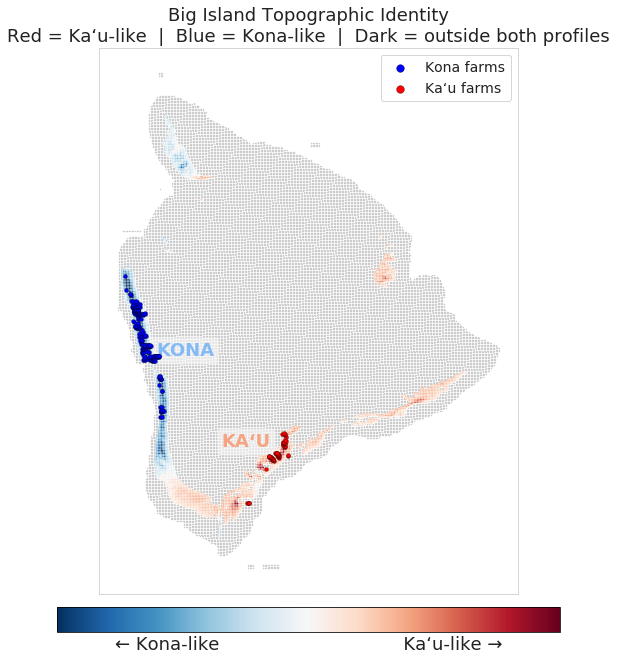

Saved 04_island_identity_map.png
Kaʻu-like: 4.8%   Kona-like: 3.8%   Neither: 91.3% of Big Island land


In [15]:
# ── C3: Island-wide identity map ─────────────────────────────────────────────
from matplotlib.colors import DivergingNorm

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_aspect(1 / np.cos(np.radians(19.6)))  # geographic aspect at ~19.6°N

# Plot out-of-range cells first as a dark neutral color
out_of_range = np.isnan(identity_isl_masked)
ax.scatter(
    lon_flat[out_of_range], lat_flat[out_of_range],
    c='#cccccc', s=2, linewidths=0, rasterized=False, zorder=1,
)

# Plot scored cells on top
in_range = ~out_of_range
vmax = np.nanpercentile(np.abs(identity_isl_masked), 97)
sc = ax.scatter(
    lon_flat[in_range], lat_flat[in_range],
    c=identity_isl_masked[in_range],
    cmap='RdBu_r',
    norm=DivergingNorm(vcenter=0, vmin=-vmax, vmax=vmax),
    s=2, linewidths=0, rasterized=True, zorder=2,
)

# Re-extract coffee lon/lat from UTM centroids
tr_inv = Transformer.from_crs('EPSG:32604', 'EPSG:4326', always_xy=True)
lon_coffee_ok, lat_coffee_ok = tr_inv.transform(cx_utm, cy_utm)

ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
           c='blue', s=15, zorder=5, linewidths=0.3, edgecolors='k',
           label='Kona farms')
ax.scatter(lon_coffee_ok[kau_isl_mask],  lat_coffee_ok[kau_isl_mask],
           c='red', s=15, zorder=5, linewidths=0.3, edgecolors='k',
           label="Kaʻu farms")

ax.text(-155.7, 19.5, 'KONA',
        color='#7eb8f7', fontsize=18, fontweight='bold', alpha=0.95,
        ha='right',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))
ax.text(-155.60, 19.23, "KAʻU",
        color='#f7a07e', fontsize=18, fontweight='bold', alpha=0.95,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))
# ax.text(-155.05, 19.75, 'HILO',   color='#aaaaaa', fontsize=10, alpha=0.7)
# ax.text(-155.75, 20.15, 'KOHALA', color='#aaaaaa', fontsize=10, alpha=0.7)

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', shrink=0.55, pad=0.02)
cbar.set_label('← Kona-like                                Kaʻu-like →',
               color='#222222', fontsize=18)
cbar.ax.tick_params(colors='#222222')
# cbar.ax.ticks([])
cbar.set_ticks([])
legend = ax.legend(facecolor='white', framealpha=0.8, loc='upper right', fontsize = 14)
for text in legend.get_texts():
    text.set_color('#222222')

ax.set_title(
    'Big Island Topographic Identity\nRed = Kaʻu-like  |  Blue = Kona-like  |  Dark = outside both profiles',
    color='#222222', fontsize=18,
)
ax.set_xlabel('', color='#222222', fontsize = 18)
ax.set_ylabel('',  color='#222222', fontsize = 18)
ax.set_xticks([])
ax.set_yticks([])
# ax.tick_params(colors='#222222', labelsize = 15)
for handle in legend.legendHandles:
    handle.set_sizes([60])  # <-- increase (try 60–120)
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig(f'{IMG}/04_island_identity_map.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print('Saved 04_island_identity_map.png')
print(f"Kaʻu-like: {n_kau/n_land_total*100:.1f}%   "
      f"Kona-like: {n_kona/n_land_total*100:.1f}%   "
      f"Neither: {n_neither/n_land_total*100:.1f}% of Big Island land")